In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from collections import Counter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
BASE_DIR = "../data"
#so pls place the 3 dataset files in a folder named data same level as the readme file on your device's repo clone folder, ty
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
VAL_DIR = os.path.join(BASE_DIR, "Validation")
TEST_DIR = os.path.join(BASE_DIR, "Test")

print(TRAIN_DIR)

print(os.listdir(TRAIN_DIR))
print(os.listdir(VAL_DIR))
print(os.listdir(TEST_DIR))

../data\Train
['WithMask', 'WithoutMask']
['WithMask', 'WithoutMask']
['WithMask', 'WithoutMask']


In [5]:
#make sure they're all the same in type first
#seems like they're all png, we'll check if there's sth else
splits = {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}

valid_extensions = {".png"}
non_png_files = []

for split_name, split_dir in splits.items():
    for class_name in ["WithMask", "WithoutMask"]:
        class_dir = os.path.join(split_dir, class_name)

        for filename in os.listdir(class_dir):
            file_path = os.path.join(class_dir, filename)

            if os.path.isfile(file_path):
                extension = os.path.splitext(filename)[1].lower()

                if extension not in valid_extensions:
                    non_png_files.append({
                        "Dataset": split_name,
                        "Class": class_name,
                        "Filename": filename,
                        "Extension": extension
                    })

if len(non_png_files) == 0:
    print("All files in the dataset are PNG files.")
else:
    print(f"Found {len(non_png_files)} non-PNG files.")
    pd.DataFrame(non_png_files)

All files in the dataset are PNG files.


In [6]:
#make a table to see the result easier
results = []

for split_name, split_dir in splits.items():
    for class_name in ["WithMask", "WithoutMask"]:
        class_dir = os.path.join(split_dir, class_name)

        count = len(os.listdir(class_dir))

        results.append({
            "Dataset": split_name,
            "Class": class_name,
            "Number of Images": count
        })

df_counts = pd.DataFrame(results)
df_counts

,Dataset,Class,Number of Images
0,Train,WithMask,5000
1,Train,WithoutMask,5000
2,Validation,WithMask,400
3,Validation,WithoutMask,400
4,Test,WithMask,483
5,Test,WithoutMask,509


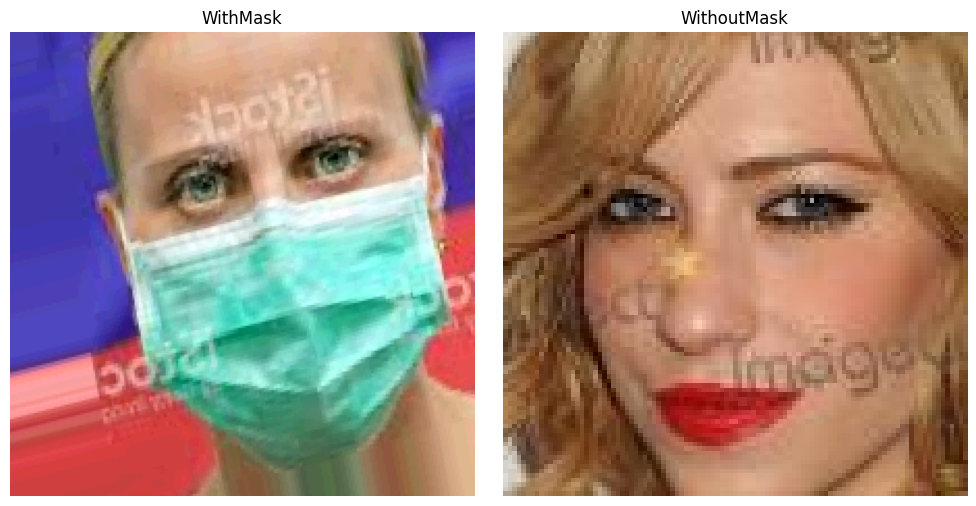

In [ ]:
#randomly open one mask pic and one no-mask pic
classes = ["WithMask", "WithoutMask"]

plt.figure(figsize=(10, 5))

for i, class_name in enumerate(classes):

    class_dir = os.path.join(TRAIN_DIR, class_name)
    image_name = random.choice(os.listdir(class_dir))
    image_path = os.path.join(class_dir, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#count number of images in each size to see if we need to resize them
image_sizes = []

for class_name in classes:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    for filename in os.listdir(class_dir):
        image_path = os.path.join(class_dir, filename)
        with Image.open(image_path) as image:
            image_sizes.append(image.size)
size_counts = Counter(image_sizes)

size_counts.most_common(10)
#yes we do need resizing

[((224, 224), 4253),
 ((107, 107), 234),
 ((106, 106), 228),
 ((105, 105), 225),
 ((102, 102), 220),
 ((103, 103), 218),
 ((101, 101), 216),
 ((108, 108), 210),
 ((104, 104), 206),
 ((100, 100), 194)]

In [ ]:
#check if they're all RGB or there's sth else
image_modes = Counter()

for class_name in classes:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    for filename in os.listdir(class_dir):
        image_path = os.path.join(class_dir, filename)
        with Image.open(image_path) as image:
            image_modes[image.mode] += 1

image_modes
#cool

Counter({'RGB': 10000})